Importing Requried libraries

In [1]:
import pandas as pd
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score,confusion_matrix
from sklearn.inspection import permutation_importance

Load the dataset and perform some basics analysis

In [2]:
df = pd.read_csv("CC GENERAL.csv")

In [3]:
df.head()

,CUST_ID,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,C10001,40.900749,0.818182,95.40,0.00,95.4,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12
1,C10002,3202.467416,0.909091,0.00,0.00,0.0,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12
2,C10003,2495.148862,1.000000,773.17,773.17,0.0,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12
3,C10004,1666.670542,0.636364,1499.00,1499.00,0.0,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,NaN,0.000000,12
4,C10005,817.714335,1.000000,16.00,16.00,0.0,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12


In [4]:
df.shape

(8950, 18)

In [5]:
df.isnull().sum()

CUST_ID                               0
BALANCE                               0
BALANCE_FREQUENCY                     0
PURCHASES                             0
ONEOFF_PURCHASES                      0
INSTALLMENTS_PURCHASES                0
CASH_ADVANCE                          0
PURCHASES_FREQUENCY                   0
ONEOFF_PURCHASES_FREQUENCY            0
PURCHASES_INSTALLMENTS_FREQUENCY      0
CASH_ADVANCE_FREQUENCY                0
CASH_ADVANCE_TRX                      0
PURCHASES_TRX                         0
CREDIT_LIMIT                          1
PAYMENTS                              0
MINIMUM_PAYMENTS                    313
PRC_FULL_PAYMENT                      0
TENURE                                0
dtype: int64

In [6]:
df.duplicated().sum()

np.int64(0)

In [7]:
na_col = ["CREDIT_LIMIT","MINIMUM_PAYMENTS"]
for col in na_col:
    df[col].fillna(df[col].mean(), inplace=True)
df.isnull().sum()    

C:\Users\ADMIN\AppData\Local\Temp\ipykernel_548\1866882362.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mean(), inplace=True)


CUST_ID                             0
BALANCE                             0
BALANCE_FREQUENCY                   0
PURCHASES                           0
ONEOFF_PURCHASES                    0
INSTALLMENTS_PURCHASES              0
CASH_ADVANCE                        0
PURCHASES_FREQUENCY                 0
ONEOFF_PURCHASES_FREQUENCY          0
PURCHASES_INSTALLMENTS_FREQUENCY    0
CASH_ADVANCE_FREQUENCY              0
CASH_ADVANCE_TRX                    0
PURCHASES_TRX                       0
CREDIT_LIMIT                        0
PAYMENTS                            0
MINIMUM_PAYMENTS                    0
PRC_FULL_PAYMENT                    0
TENURE                              0
dtype: int64

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8950 entries, 0 to 8949
Data columns (total 18 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   CUST_ID                           8950 non-null   object 
 1   BALANCE                           8950 non-null   float64
 2   BALANCE_FREQUENCY                 8950 non-null   float64
 3   PURCHASES                         8950 non-null   float64
 4   ONEOFF_PURCHASES                  8950 non-null   float64
 5   INSTALLMENTS_PURCHASES            8950 non-null   float64
 6   CASH_ADVANCE                      8950 non-null   float64
 7   PURCHASES_FREQUENCY               8950 non-null   float64
 8   ONEOFF_PURCHASES_FREQUENCY        8950 non-null   float64
 9   PURCHASES_INSTALLMENTS_FREQUENCY  8950 non-null   float64
 10  CASH_ADVANCE_FREQUENCY            8950 non-null   float64
 11  CASH_ADVANCE_TRX                  8950 non-null   int64  
 12  PURCHA

In [9]:
df.describe()

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
count,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000
mean,1564.474828,0.877271,1003.204834,592.437371,411.067645,978.871112,0.490351,0.202458,0.364437,0.135144,3.248827,14.709832,4494.449450,1733.143852,864.206542,0.153715,11.517318
std,2081.531879,0.236904,2136.634782,1659.887917,904.338115,2097.163877,0.401371,0.298336,0.397448,0.200121,6.824647,24.857649,3638.612411,2895.063757,2330.588021,0.292499,1.338331
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,50.000000,0.000000,0.019163,0.000000,6.000000
25%,128.281915,0.888889,39.635000,0.000000,0.000000,0.000000,0.083333,0.000000,0.000000,0.000000,0.000000,1.000000,1600.000000,383.276166,170.857654,0.000000,12.000000
50%,873.385231,1.000000,361.280000,38.000000,89.000000,0.000000,0.500000,0.083333,0.166667,0.000000,0.000000,7.000000,3000.000000,856.901546,335.628312,0.000000,12.000000
75%,2054.140036,1.000000,1110.130000,577.405000,468.637500,1113.821139,0.916667,0.300000,0.750000,0.222222,4.000000,17.000000,6500.000000,1901.134317,864.206542,0.142857,12.000000
max,19043.138560,1.000000,49039.570000,40761.250000,22500.000000,47137.211760,1.000000,1.000000,1.000000,1.500000,123.000000,358.000000,30000.000000,50721.483360,76406.207520,1.000000,12.000000


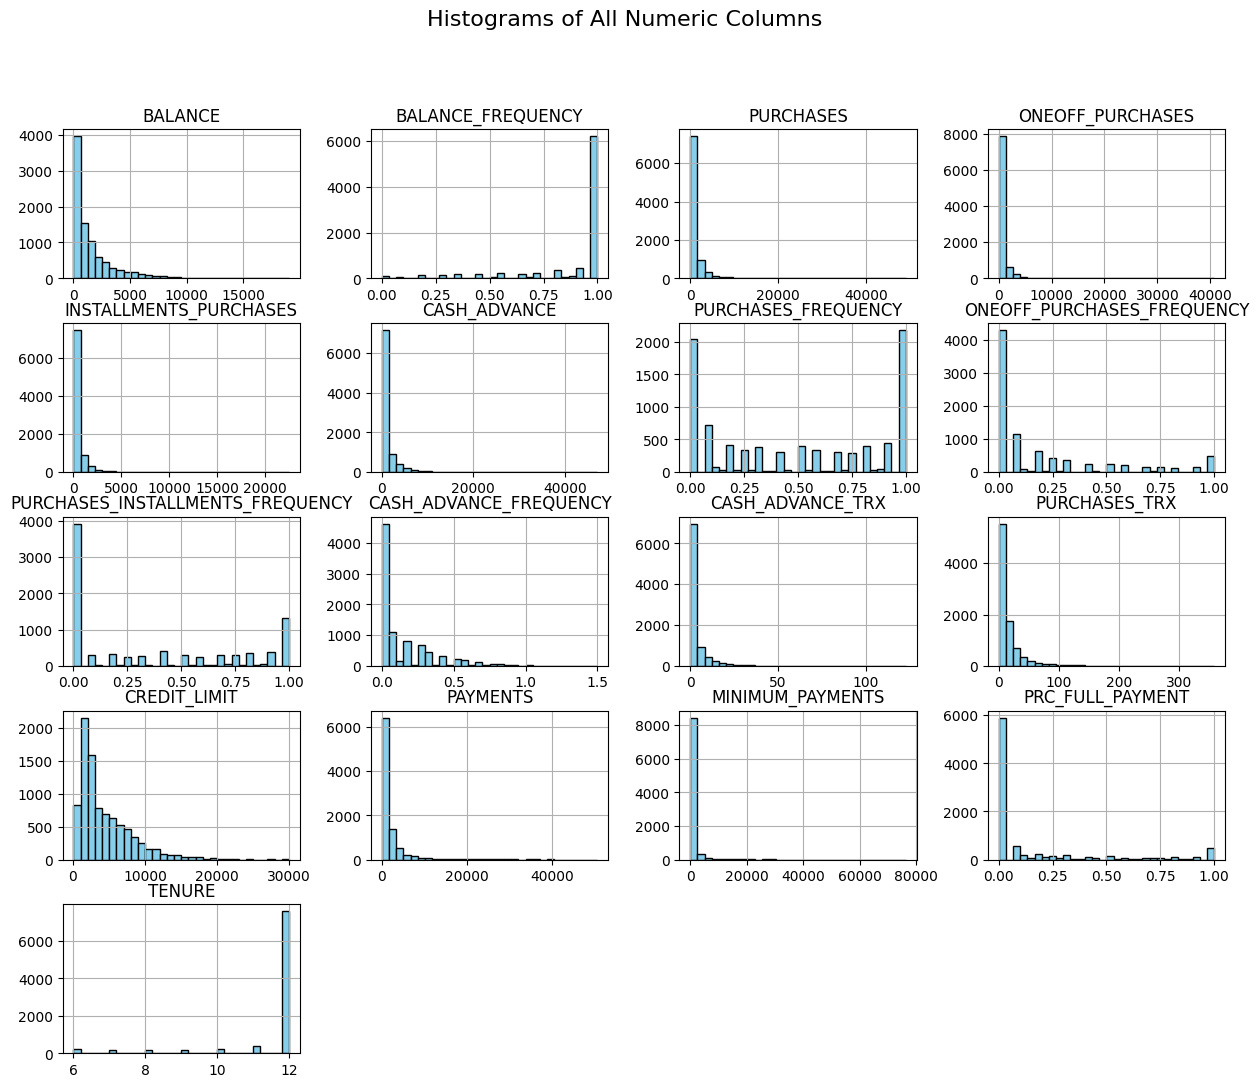

In [10]:
df.hist(figsize=(15, 12), bins=30, color='skyblue', edgecolor='black')
plt.suptitle('Histograms of All Numeric Columns', fontsize=16)
plt.show()

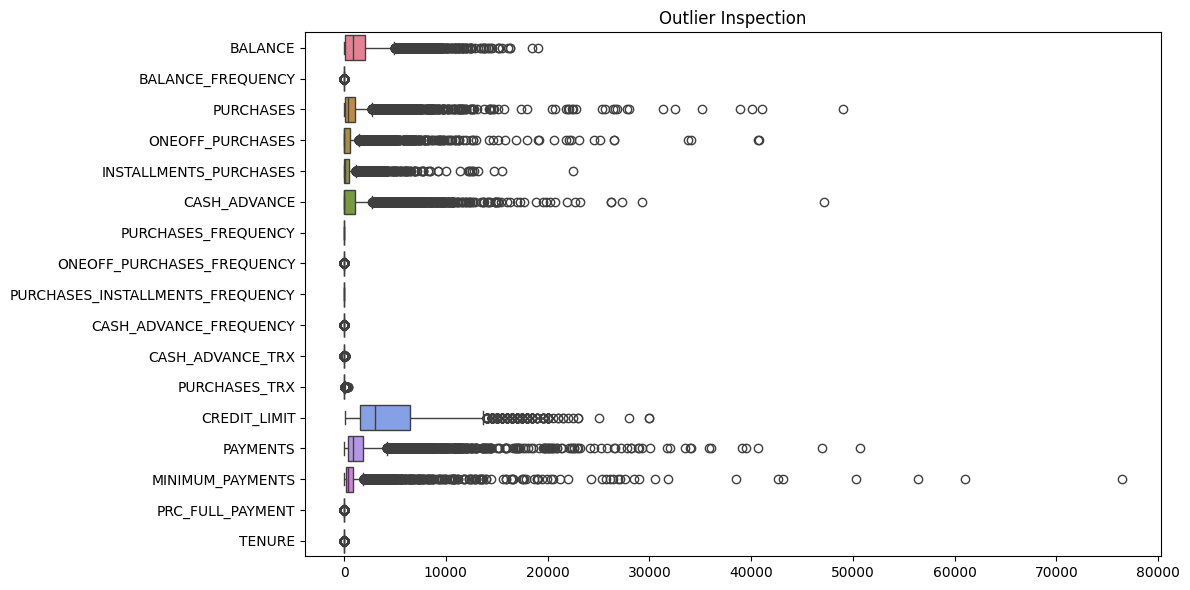

In [11]:
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns

plt.figure(figsize=(12,6))
sns.boxplot(data=df[numeric_cols], orient='h')
plt.title("Outlier Inspection")
plt.tight_layout()
plt.show()

Drop the unecessary columns

In [12]:
df.drop("CUST_ID", axis=1, inplace=True)

In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8950 entries, 0 to 8949
Data columns (total 17 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   BALANCE                           8950 non-null   float64
 1   BALANCE_FREQUENCY                 8950 non-null   float64
 2   PURCHASES                         8950 non-null   float64
 3   ONEOFF_PURCHASES                  8950 non-null   float64
 4   INSTALLMENTS_PURCHASES            8950 non-null   float64
 5   CASH_ADVANCE                      8950 non-null   float64
 6   PURCHASES_FREQUENCY               8950 non-null   float64
 7   ONEOFF_PURCHASES_FREQUENCY        8950 non-null   float64
 8   PURCHASES_INSTALLMENTS_FREQUENCY  8950 non-null   float64
 9   CASH_ADVANCE_FREQUENCY            8950 non-null   float64
 10  CASH_ADVANCE_TRX                  8950 non-null   int64  
 11  PURCHASES_TRX                     8950 non-null   int64  
 12  CREDIT

Use K-means to create two clusters

In [14]:
# Use CREDIT_LIMIT and PURCHASES for clustering

km_data = df[['CREDIT_LIMIT', 'PURCHASES']].copy()

# handle missing values (drop or fill); here drop rows with NaN in these two cols

km_data = km_data.dropna()
scaler_km = StandardScaler()
km_scaled = scaler_km.fit_transform(km_data)
kmeans = KMeans(n_clusters=2, random_state=42)
km_labels = kmeans.fit_predict(km_scaled)

# create label column aligned to original df (rows with dropped values get NaN)

df['high_value_label'] = np.nan
df.loc[km_data.index, 'high_value_label'] = km_labels

# Optionally pick cluster 1 as 'high-value' — but clusters unlabeled, so inspect means:

cluster_mean = df.groupby('high_value_label')[['CREDIT_LIMIT','PURCHASES']].mean()
print("Cluster means (inspect to decide which cluster is high-value):")
print(cluster_mean)

# Convert labels to ints and if needed make the cluster with higher mean purchases+limit label=1

cluster_score = (cluster_mean['CREDIT_LIMIT'] + cluster_mean['PURCHASES'])
high_cluster = cluster_score.idxmax()
df['high_value_label'] = (df['high_value_label'] == high_cluster).astype(int)
print("Labels created using KMeans clustering. Class distribution:")
print(df['high_value_label'].value_counts())
df = df.reset_index(drop=True)

Cluster means (inspect to decide which cluster is high-value):
                  CREDIT_LIMIT    PURCHASES
high_value_label                           
0.0                9665.303317  2515.724797
1.0                2893.406609   534.885805
Labels created using KMeans clustering. Class distribution:
high_value_label
0    6834
1    2116
Name: count, dtype: int64


Top 30% by credit limit AND top 30% by purchase amount

Labels created using top-30% rule. Class distribution:
high_value_label
0    7672
1    1278
Name: count, dtype: int64


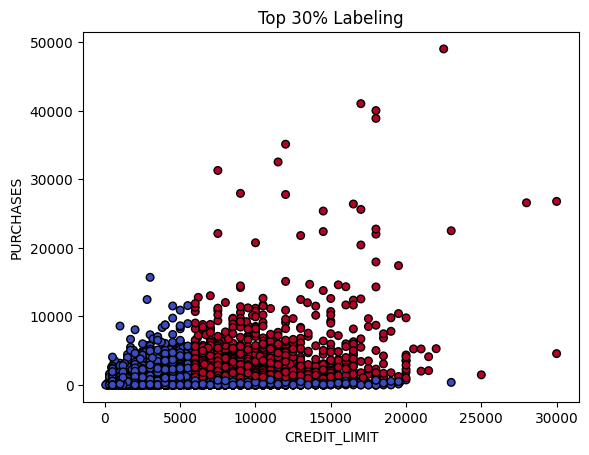

In [15]:
df_top30 = df.copy()
lim_threshold = df['CREDIT_LIMIT'].quantile(0.70)  # top 30% => 70th percentile
pur_threshold = df['PURCHASES'].quantile(0.70)
df['high_value_label'] = ((df['CREDIT_LIMIT'] >= lim_threshold) & (df['PURCHASES'] >= pur_threshold)).astype(int)
print("Labels created using top-30% rule. Class distribution:")
print(df['high_value_label'].value_counts())

df_top30['label_top30'] = ((df_top30['CREDIT_LIMIT'] >= lim_threshold) & 
                           (df_top30['PURCHASES'] >= pur_threshold)).astype(int)
fig=figsize=(12, 5)

plt.scatter(df_top30['CREDIT_LIMIT'], df_top30['PURCHASES'],
                c=df_top30['label_top30'], cmap='coolwarm', s=30, edgecolors='k')
plt.title('Top 30% Labeling')
plt.xlabel('CREDIT_LIMIT')
plt.ylabel('PURCHASES')

df = df.reset_index(drop=True)


In [16]:
df.head()

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE,high_value_label
0,40.900749,0.818182,95.40,0.00,95.4,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12,0
1,3202.467416,0.909091,0.00,0.00,0.0,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12,0
2,2495.148862,1.000000,773.17,773.17,0.0,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12,0
3,1666.670542,0.636364,1499.00,1499.00,0.0,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,864.206542,0.000000,12,1
4,817.714335,1.000000,16.00,16.00,0.0,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12,0


Select two features (BALANCE, PURCHASES), filter outliers for clearer separation

In [17]:
# TASK - Select two features (BALANCE, PURCHASES), filter outliers for clearer separation
feature_x = 'BALANCE'
feature_y = 'PURCHASES'

# Keep rows where both features and label are present
vis_df = df[[feature_x, feature_y, 'high_value_label']].dropna()

# Filter extreme outliers by percentile to create clearer separation (e.g., keep 1st-99th percentile)
low_q, high_q = 0.01, 0.99
x_low, x_high = vis_df[feature_x].quantile(low_q), vis_df[feature_x].quantile(high_q)
y_low, y_high = vis_df[feature_y].quantile(low_q), vis_df[feature_y].quantile(high_q)

vis_df = vis_df[(vis_df[feature_x] >= x_low) & (vis_df[feature_x] <= x_high) &
                (vis_df[feature_y] >= y_low) & (vis_df[feature_y] <= y_high)].copy()

print(f"Visualization dataset size after filtering rows")

Visualization dataset size after filtering rows


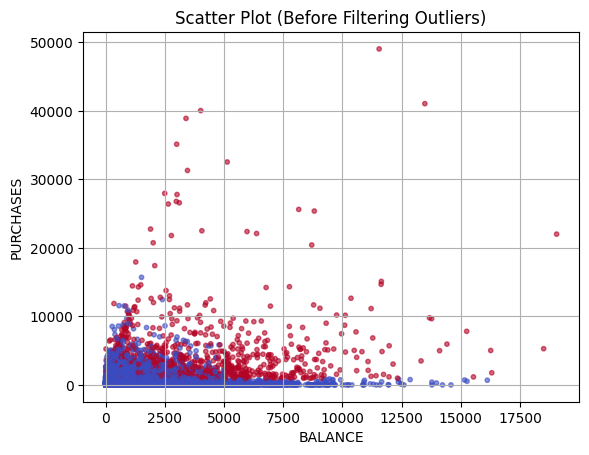

In [18]:
# Scatter plot comparison: Before vs After filtering
plt.scatter(df[feature_x], df[feature_y], 
            c=df['high_value_label'], cmap='coolwarm', s=10, alpha=0.6)
plt.title("Scatter Plot (Before Filtering Outliers)")
plt.xlabel(feature_x)
plt.ylabel(feature_y)
plt.grid(True)

plt.show()

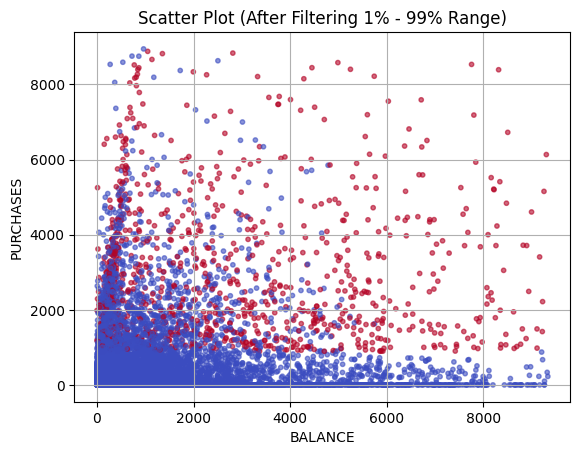

In [19]:
plt.scatter(vis_df[feature_x], vis_df[feature_y], 
            c=vis_df['high_value_label'], cmap='coolwarm', s=10, alpha=0.6)
plt.title("Scatter Plot (After Filtering 1% - 99% Range)")
plt.xlabel(feature_x)
plt.ylabel(feature_y)
plt.grid(True)
plt.show()

 Standardize features for SVM

In [20]:
# Standardize features for SVM (important for margin scale)
scaler = StandardScaler()
X = scaler.fit_transform(vis_df[[feature_x, feature_y]].values)
Y = vis_df['high_value_label'].values.astype(int)

Scatter plot of the two features with class labels

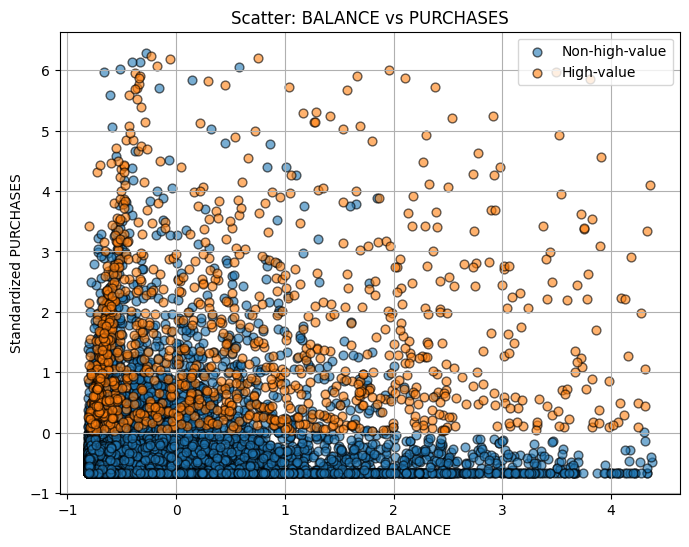

In [21]:
# TASK - Scatter plot of the two features with class labels (visual intuition)
plt.figure(figsize=(8,6))
for label_val, label_name in zip([0,1], ['Non-high-value','High-value']):
    mask = (Y == label_val)
    plt.scatter(X[mask, 0], X[mask, 1], label=label_name, alpha=0.6, edgecolors='k', s=40)

plt.xlabel(f"Standardized {feature_x}")
plt.ylabel(f"Standardized {feature_y}")
plt.title(f"Scatter: {feature_x} vs {feature_y}")
plt.legend()
plt.grid(True)
plt.show()

Train linear SVM for these 2 features(C=1)

In [22]:
# TASK - Train Linear SVM (C=1) and visualize decision boundary, margin, support vectors, and compute margin width
C_val = 1.0
svm_clf = SVC(kernel='linear', C=C_val)
svm_clf.fit(X, Y)

SVC(kernel='linear')

In [23]:
# Access coefficients for margin calculation
w = svm_clf.coef_[0]  # shape (2,)
b = svm_clf.intercept_[0]

# Margin width = 2 / ||w||  (in standardized feature space)
margin_width = 2.0 / np.linalg.norm(w)
print(f"C = {C_val} --> margin width (in standardized space) = {margin_width:.4f}")

# Plot decision boundary, margins, and support vectors
xx_min, xx_max = X[:,0].min() - 1, X[:,0].max() + 1
yy_min, yy_max = X[:,1].min() - 1, X[:,1].max() + 1
xx, yy = np.meshgrid(np.linspace(xx_min, xx_max, 500), np.linspace(yy_min, yy_max, 500))
grid = np.c_[xx.ravel(), yy.ravel()]
Z = svm_clf.decision_function(grid).reshape(xx.shape)

C = 1.0 --> margin width (in standardized space) = 2.9660


Plot the scatter plot for the trained svm with 2 features

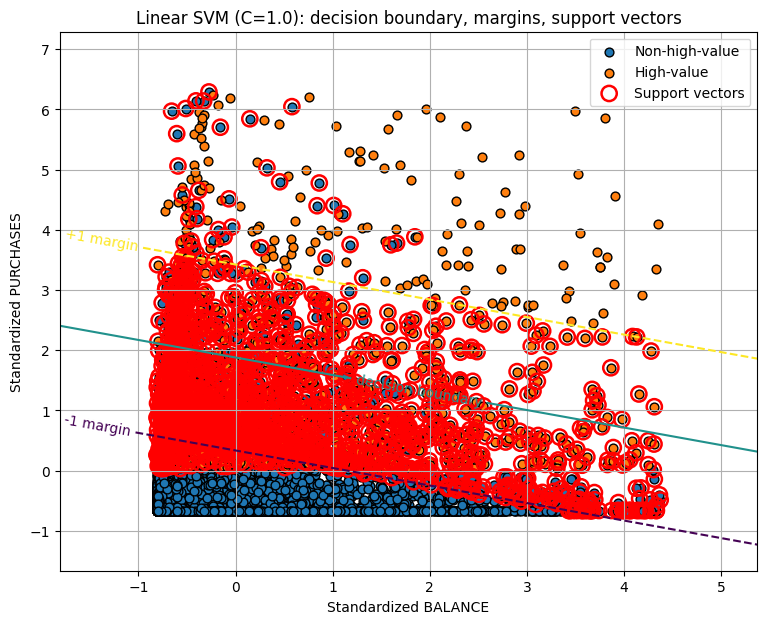

In [24]:
plt.figure(figsize=(9,7))
# contour for decision function
contour = plt.contour(xx, yy, Z, levels=[-1.0, 0.0, 1.0], linestyles=['--','-','--'])
plt.clabel(contour, fmt={-1.0:'-1 margin', 0.0:'decision boundary', 1.0:'+1 margin'}, inline=1)

# scatter points
plt.scatter(X[Y==0,0], X[Y==0,1], label='Non-high-value', edgecolors='k', s=40)
plt.scatter(X[Y==1,0], X[Y==1,1], label='High-value', edgecolors='k', s=40)

# highlight support vectors
sv = svm_clf.support_vectors_
plt.scatter(sv[:,0], sv[:,1], s=120, facecolors='none', edgecolors='r', linewidths=1.8, label='Support vectors')

plt.xlabel(f"Standardized {feature_x}")
plt.ylabel(f"Standardized {feature_y}")
plt.title(f"Linear SVM (C={C_val}): decision boundary, margins, support vectors")
plt.legend()
plt.grid(True)
plt.show()


Plot the graph for different x values

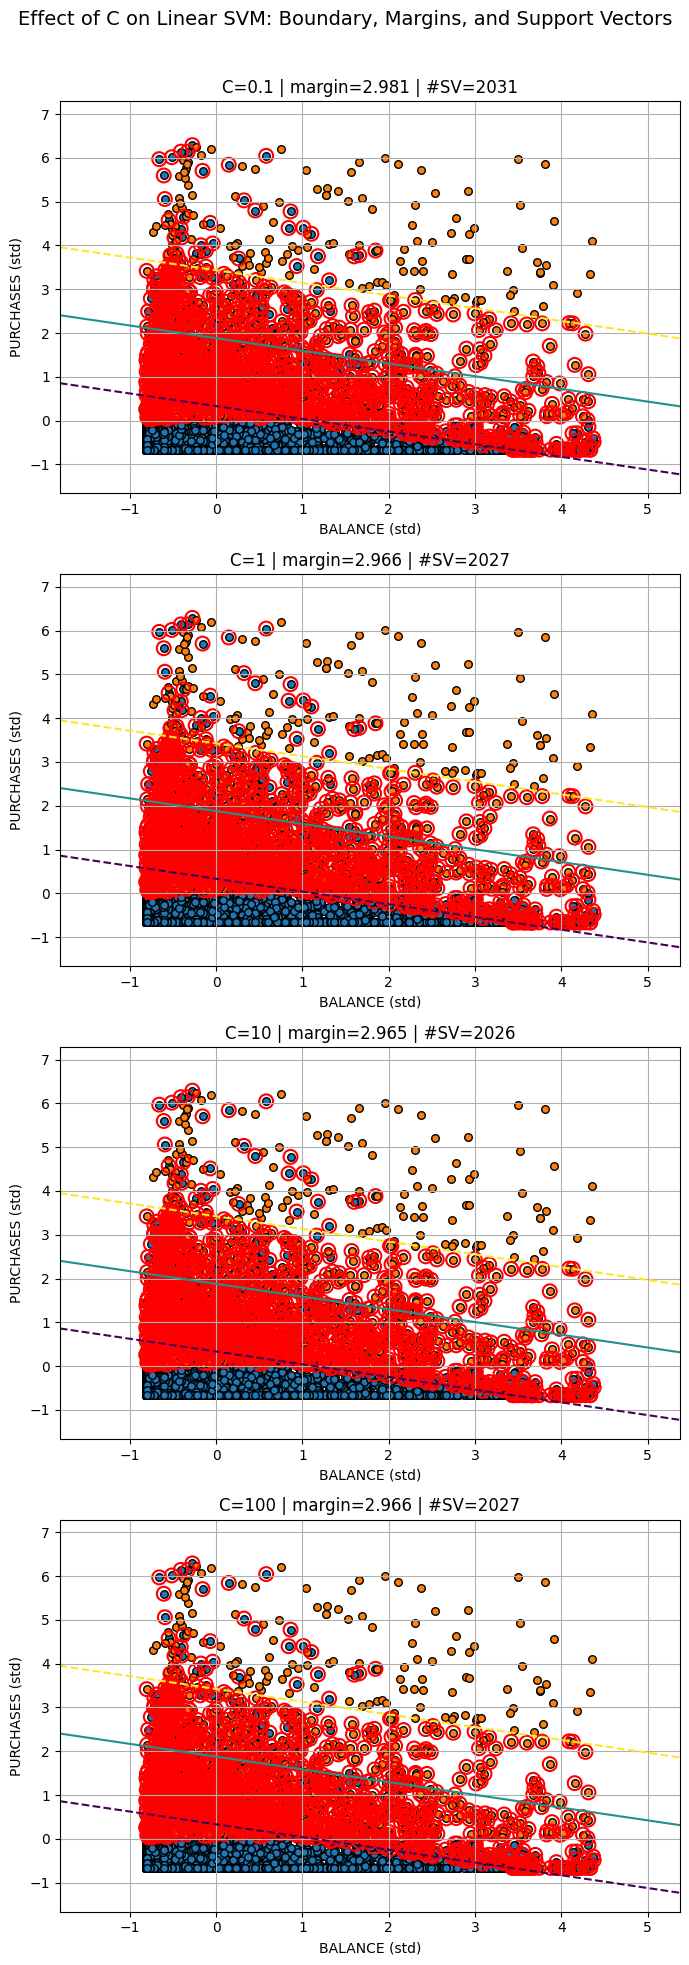

In [25]:
#(UPDATED): TASK - Effect of C parameter (stacked vertically, one per row)
C_list = [0.1, 1, 10, 100]
fig, axes = plt.subplots(len(C_list), 1, figsize=(7, 5 * len(C_list)))

xx_min, xx_max = X[:,0].min() - 1, X[:,0].max() + 1
yy_min, yy_max = X[:,1].min() - 1, X[:,1].max() + 1
xx, yy = np.meshgrid(np.linspace(xx_min, xx_max, 300), np.linspace(yy_min, yy_max, 300))
grid = np.c_[xx.ravel(), yy.ravel()]

for ax, Cval in zip(axes.flat, C_list):
    clf = SVC(kernel='linear', C=Cval)
    clf.fit(X, Y)
    Z = clf.decision_function(grid).reshape(xx.shape)
    
    ax.contour(xx, yy, Z, levels=[-1.0, 0.0, 1.0], linestyles=['--','-','--'])
    ax.scatter(X[Y==0,0], X[Y==0,1], s=30, edgecolors='k')
    ax.scatter(X[Y==1,0], X[Y==1,1], s=30, edgecolors='k')
    
    sv = clf.support_vectors_
    ax.scatter(sv[:,0], sv[:,1], s=100, facecolors='none', edgecolors='r', linewidths=1.5)
    
    w = clf.coef_[0]
    margin = 2.0 / np.linalg.norm(w)
    
    ax.set_title(f"C={Cval} | margin={margin:.3f} | #SV={len(sv)}", fontsize=12)
    ax.set_xlabel(f"{feature_x} (std)")
    ax.set_ylabel(f"{feature_y} (std)")
    ax.grid(True)

plt.suptitle("Effect of C on Linear SVM: Boundary, Margins, and Support Vectors", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()


In [26]:
df.head()

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE,high_value_label
0,40.900749,0.818182,95.40,0.00,95.4,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12,0
1,3202.467416,0.909091,0.00,0.00,0.0,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12,0
2,2495.148862,1.000000,773.17,773.17,0.0,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12,0
3,1666.670542,0.636364,1499.00,1499.00,0.0,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,864.206542,0.000000,12,1
4,817.714335,1.000000,16.00,16.00,0.0,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12,0


Seperate the colums as x and y

In [27]:
x= df.drop("high_value_label",axis=1)
y = df["high_value_label"]

In [28]:
x.shape

(8950, 17)

In [29]:
y.shape

(8950,)

Data spliting as train validation and training

In [30]:
x_train,x_temp,y_train,y_temp = train_test_split(x,y,test_size=0.4,random_state=42, stratify=y)
x_test,x_val,y_test,y_val = train_test_split(x_temp,y_temp,test_size=0.5,random_state=42,stratify=y_temp)

Scaling the values before adding smote data

In [31]:
std = StandardScaler()
x_train_scaled = std.fit_transform(x_train)
x_val_scaled = std.transform(x_val)
x_test_scaled = std.transform(x_test)

Adding smote data to reduce the class imbalance

In [32]:
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(x_train_scaled, y_train)

In [33]:
print("Original class distribution:", y_train.value_counts())
print("After SMOTE:", y_train_smote.value_counts())

Original class distribution: high_value_label
0    4603
1     767
Name: count, dtype: int64
After SMOTE: high_value_label
0    4603
1    4603
Name: count, dtype: int64


In [34]:
print(X_train_smote.shape)
print(y_train_smote.shape)
print(x_test.shape)
print(y_test.shape)
print(x_val.shape) 
print(y_val.shape)

(9206, 17)
(9206,)
(1790, 17)
(1790,)
(1790, 17)
(1790,)


Implemented SVM for different C values and find the best one

In [35]:
C_values = [0.01, 0.1, 1, 10, 100]
best_C = None
best_val_score = -1
best_model = None

for Cval in C_values:
    model = SVC(kernel='linear', C=Cval, class_weight='balanced',probability=True)
    model.fit(X_train_smote, y_train_smote)
    val_score = model.score(x_val_scaled, y_val)
    print(f"C={Cval} -> Validation Accuracy = {val_score}")
    
    if val_score > best_val_score:
        best_val_score = val_score
        best_C = Cval
        best_model = model

print(f"\nBest C value based on validation set: {best_C}")

C=0.01 -> Validation Accuracy = 0.8932960893854749
C=0.1 -> Validation Accuracy = 0.8960893854748604
C=1 -> Validation Accuracy = 0.8960893854748604
C=10 -> Validation Accuracy = 0.8960893854748604
C=100 -> Validation Accuracy = 0.8960893854748604

Best C value based on validation set: 0.1


Checking the test accuracy of the model

In [36]:
y_pred_test = best_model.predict(x_test_scaled)

acc = accuracy_score(y_test, y_pred_test)
prec = precision_score(y_test, y_pred_test)
rec = recall_score(y_test, y_pred_test)
f1 = f1_score(y_test, y_pred_test)
cm = confusion_matrix(y_test, y_pred_test)
print("Confusion Matrix:\n", cm)
print("SVM Performance on Test Set:")
print(f"Accuracy:  {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall:    {rec:.4f}")
print(f"F1 Score:  {f1:.4f}")

Confusion Matrix:
 [[1353  181]
 [  17  239]]
SVM Performance on Test Set:
Accuracy:  0.8894
Precision: 0.5690
Recall:    0.9336
F1 Score:  0.7071


Ploted the confusion matrix for trained model

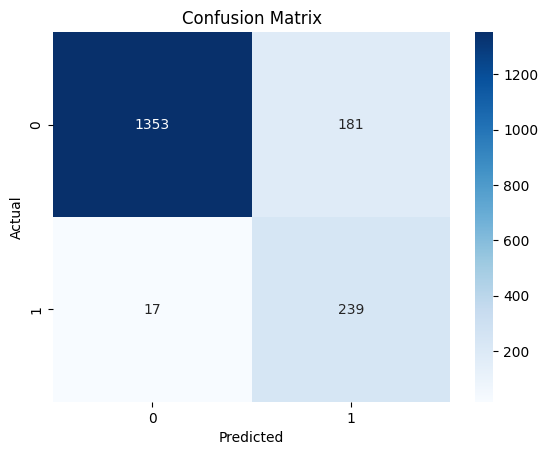

In [37]:
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

Implemented the logistic regression for comparision

In [38]:
from sklearn.linear_model import LogisticRegression

log_reg = LogisticRegression(max_iter=1000)
log_reg.fit(X_train_smote, y_train_smote)
y_pred_lr = log_reg.predict(x_test_scaled)

acc_lr = accuracy_score(y_test, y_pred_lr)
prec_lr = precision_score(y_test, y_pred_lr)
rec_lr = recall_score(y_test, y_pred_lr)
f1_lr = f1_score(y_test, y_pred_lr)

In [39]:
print("Logistic Regression Performance on Test Set:")
print(f"Accuracy:  {acc_lr:.4f}")
print(f"Precision: {prec_lr:.4f}")
print(f"Recall:    {rec_lr:.4f}")
print(f"F1 Score:  {f1_lr:.4f}")

Logistic Regression Performance on Test Set:
Accuracy:  0.8966
Precision: 0.5903
Recall:    0.9062
F1 Score:  0.7149


Extract and visualize top 10 feature weights

Top 10 Most Important Features (RBF SVM):
CREDIT_LIMIT                  0.112570
PURCHASES_FREQUENCY           0.014078
ONEOFF_PURCHASES              0.012235
PURCHASES                     0.010726
INSTALLMENTS_PURCHASES        0.006201
PAYMENTS                      0.005475
CASH_ADVANCE                  0.003520
PURCHASES_TRX                 0.003408
ONEOFF_PURCHASES_FREQUENCY    0.003352
BALANCE                       0.002961
dtype: float64


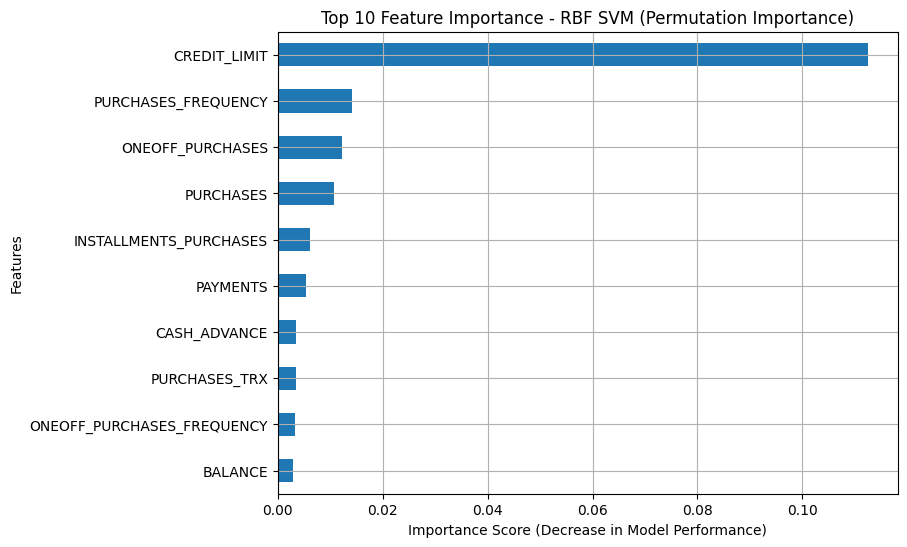

In [40]:
# Compute permutation importance
result = permutation_importance(best_model, x_test_scaled, y_test, n_repeats=10, random_state=42)

# Extract feature importance
importances = pd.Series(result.importances_mean, index=x.columns)

# Select top 10 features
top_10_importances = importances.abs().sort_values(ascending=False).head(10)

print("Top 10 Most Important Features (RBF SVM):")
print(top_10_importances)

# Plot
top_10_importances.sort_values().plot(kind='barh', figsize=(8,6))
plt.title("Top 10 Feature Importance - RBF SVM (Permutation Importance)")
plt.xlabel("Importance Score (Decrease in Model Performance)")
plt.ylabel("Features")
plt.grid(True)
plt.show()


Identify the borderline customers

In [41]:
# Convert SMOTE results back into DataFrame
X_train_smote_df = pd.DataFrame(X_train_smote, columns=x_train.columns)

# Identify borderline (support vector) samples
borderline_indices = best_model.support_
borderline_customers = X_train_smote_df.iloc[borderline_indices]

print("Number of borderline customers:", len(borderline_customers))
display(borderline_customers.head())


Number of borderline customers: 2019


,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
2,1.405264,0.530696,-0.463837,-0.351271,-0.464232,-0.011186,-1.212787,-0.672931,-0.913481,-0.260969,-0.179181,-0.598320,1.360520,-0.133731,0.091397,-0.525415,0.361995
6,0.018289,0.530696,0.060341,0.323056,-0.464232,-0.143521,1.284529,2.694109,-0.913481,0.148154,0.109812,0.184298,-0.556909,-0.199305,0.048817,-0.525415,0.361995
21,-0.317051,0.530696,0.786791,-0.261507,2.406175,-0.461812,1.284529,0.449414,1.612889,-0.670087,-0.468174,1.008107,-0.556909,-0.020103,-0.232283,-0.525415,0.361995
24,1.354689,0.530696,0.069113,0.334341,-0.464232,0.445019,0.243980,1.291174,-0.913481,1.375514,0.832294,-0.062844,0.127887,-0.166532,0.201601,-0.525415,0.361995
25,0.171832,0.151986,2.139932,2.607470,0.274326,1.537626,0.452091,0.449414,-0.281889,0.966390,1.699272,1.296440,0.264846,3.073867,-0.004914,-0.146864,0.361995


Predicted the new values with the trained model

In [42]:
# Replace values below with the new customer's feature values
my_input = np.array([[40.900749, 0.818182, 95.40, 0.00, 95.4, 0.000000, 0.166667, 0.000000, 0.083333, 0.000000, 0, 2, 1000.0, 201.802084, 139.509787, 0.000000, 12]])

In [43]:
# Convert to DataFrame to ensure column alignment
new_customer_df = pd.DataFrame(my_input, columns=x_train.columns)

# Fill missing values (if any)
new_customer_df = new_customer_df.fillna(x_train.mean())

# Scale using the SAME scaler (do NOT use fit_transform)
new_customer_scaled = std.transform(new_customer_df)

# Predict using the best balanced SVM model
prediction = best_model.predict(new_customer_scaled)[0]

# Output
if prediction == 1:
    print("Predicted Class: High-Value Customer")
else:
    print("Predicted Class: Low-Value Customer")


Predicted Class: Low-Value Customer


In [44]:
proba = best_model.predict_proba(new_customer_scaled)[0]
print("Probability of Class 0:", proba[0])
print("Probability of Class 1:", proba[1])

Probability of Class 0: 0.9978435109539686
Probability of Class 1: 0.002156489046031265


In [45]:
# Replace values below with the new customer's feature values
my_input_2 = np.array([[6886.213231 , 1.000000 , 1611.70 , 0.00 , 1611.70 , 2301.491267 , 0.500000 , 0.000000 , 0.500000 , 0.166667 , 4 , 11 , 8000.0 , 1993.439277 , 2109.906490 , 0.000000 , 12]])


In [46]:
# Convert to DataFrame to ensure column alignment
new_customer_df = pd.DataFrame(my_input_2, columns=x_train.columns)

# Fill missing values (if any)
new_customer_df = new_customer_df.fillna(x_train.mean())

# Scale using the SAME scaler (do NOT use fit_transform)
new_customer_scaled = std.transform(new_customer_df)

# Predict using the best balanced SVM model
prediction = best_model.predict(new_customer_scaled)[0]

# Output
if prediction == 1:
    print("Predicted Class: High-Value Customer")
else:
    print("Predicted Class: Low-Value Customer")


Predicted Class: High-Value Customer


In [47]:
proba = best_model.predict_proba(new_customer_scaled)[0]
print("Probability of Class 0:", proba[0])
print("Probability of Class 1:", proba[1])

Probability of Class 0: 0.3547527146094625
Probability of Class 1: 0.6452472853905376
